[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KTH-EG2140/course-material/blob/main/notebooks/LC01_svedala_warmup.ipynb)

# LC1 warm-up — the Svedala grid, again

Welcome to EG2140. This notebook re-runs something most of you did in EG2130: load the Svedala transmission model and solve a power flow. It is *meant* to feel familiar — the point today is to check that everyone can run power system code, not to learn power flow.

**How to run it:** click the *Open in Colab* badge above — the notebook then runs in your browser on Google's machines, nothing installed on your laptop (you still need to be online: the grid data is downloaded too). The proper course environment is built in Lab 1.

**Running it locally instead?** If you have never used Jupyter: in a terminal, `pip install jupyterlab`, then `jupyter lab` in the folder holding this file, and open the notebook from the file list. (VS Code with the Python extension also opens `.ipynb` files directly.) Either way, the first code cell installs what the notebook needs.

*Did not take EG2130?* Work through the full self-paced exercise at [KTH-EPE/EG2130-SA-Exercise](https://github.com/KTH-EPE/EG2130-SA-Exercise) before Lab 1 — this notebook is the short version.

In [1]:
# Install what this notebook needs (quiet = less output).
# Colab pins pandas==2.2.2 - keep that pin there to avoid a runtime restart;
# locally this installs into your active environment.
import sys
pkgs = "pandapower matplotlib"
if "google.colab" in sys.modules:
    pkgs += " pandas==2.2.2"
%pip install $pkgs --quiet



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /private/tmp/claude-501/-Users-larsnordstrom-code-EG2140-dev/b312b5c1-fbe4-4a5d-996d-64114a3bca9a/scratchpad/lc01venv/bin/python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## 1. Load the Svedala model

The grid lives as five CSV files — buses, lines, transformers, generators, loads. You have used these tables for two courses. (Later in this course you will meet the CIM-XML files they were created from.)

In [2]:
import pandas as pd
import pandapower as pp

# The model lives as five CSV tables in the course's own repository on Github.
BASE = "https://raw.githubusercontent.com/KTH-EG2140/course-material/main/data/svedala"

# index_col=0: the first CSV column holds each element's ID — lines refer to
# buses BY these IDs, so they must become the DataFrame index, not data.
buses  = pd.read_csv(f"{BASE}/buses.csv", index_col=0)
lines  = pd.read_csv(f"{BASE}/lines.csv", index_col=0)
trafos = pd.read_csv(f"{BASE}/transformers.csv", index_col=0)
gens   = pd.read_csv(f"{BASE}/generators.csv", index_col=0)
loads  = pd.read_csv(f"{BASE}/loads.csv", index_col=0)

# A first sanity look: does the size match what you remember from EG2130?
print(len(buses), "buses |", len(lines), "lines |", len(trafos), "transformers |",
      len(gens), "generators |", len(loads), "loads")
# The files carry many more columns (CIM identifiers — they return later in
# the course); here we look only at the ones this notebook uses.
buses[["name", "vn_kv", "SubGeographicalRegion_name", "in_service"]].head(3)

52 buses | 52 lines | 44 transformers | 36 generators | 60 loads


,name,vn_kv,SubGeographicalRegion_name,in_service
0,AGGAN CT11_135.0kV,135.0,ZON_NORR,True
18,AGGAN CT11_400.0kV,400.0,ZON_NORR,True
51,AGGAN CT11_17.0kV,17.0,ZON_NORR,True


## 2. Build the pandapower network

We rebuild the network element by element. One detail worth noticing: the `max_i_ka` column (line current limits) is **empty in the source data**, so we fill in conservative defaults by voltage level. Remember this — it returns later in the course as an example of a data-cleaning decision.

In [3]:
# Start from an empty network and add the elements table by table.
net = pp.create_empty_network(name="Svedala")

# Buses first — everything else attaches to them. index=idx keeps the
# original IDs so the other tables' references still point correctly.
for idx, b in buses.iterrows():
    pp.create_bus(net, vn_kv=b.vn_kv, name=b["name"], zone=b.SubGeographicalRegion_name,
                  in_service=b.in_service, index=idx)

# Line current limits (max_i_ka) are EMPTY in the source data, so we fill
# conservative defaults per voltage level. An assumption, not a measurement!
DEFAULT_I_KA = {400.0: 2.0, 220.0: 1.0, 135.0: 0.9}
for idx, l in lines.iterrows():
    vn = net.bus.at[l.from_bus, "vn_kv"]
    i_ka = l.max_i_ka if pd.notna(l.max_i_ka) else DEFAULT_I_KA.get(vn, 0.5)
    pp.create_line_from_parameters(net, from_bus=l.from_bus, to_bus=l.to_bus,
        length_km=l.length_km, r_ohm_per_km=l.r_ohm_per_km, x_ohm_per_km=l.x_ohm_per_km,
        c_nf_per_km=l.c_nf_per_km, max_i_ka=i_ka, name=l["name"],
        in_service=l.in_service, index=idx)

# Transformers connect the voltage levels (hv_bus/lv_bus).
for idx, t in trafos.iterrows():
    pp.create_transformer_from_parameters(net, hv_bus=t.hv_bus, lv_bus=t.lv_bus,
        sn_mva=t.sn_mva, vn_hv_kv=t.vn_hv_kv, vn_lv_kv=t.vn_lv_kv,
        vk_percent=t.vk_percent, vkr_percent=t.vkr_percent, pfe_kw=t.pfe_kw,
        i0_percent=t.i0_percent, shift_degree=t.shift_degree, name=t["name"],
        in_service=t.in_service, index=idx)

# Generators: p_mw is the dispatch, vm_pu the voltage setpoint. Exactly one
# generator has slack=True — it balances whatever the others do not cover.
for idx, g in gens.iterrows():
    pp.create_gen(net, bus=g.bus, p_mw=g.p_mw, vm_pu=g.vm_pu, sn_mva=g.sn_mva,
        min_q_mvar=g.min_q_mvar, max_q_mvar=g.max_q_mvar, slack=g.slack,
        name=g["name"], in_service=g.in_service, index=idx)

# Loads: active and reactive power demand at their buses.
for idx, ld in loads.iterrows():
    pp.create_load(net, bus=ld.bus, p_mw=ld.p_mw, q_mvar=ld.q_mvar,
        name=ld["name"], in_service=ld.in_service, index=idx)

net

This pandapower network includes the following parameter tables:
   - bus (52 elements)
   - load (60 elements)
   - gen (36 elements)
   - line (52 elements)
   - trafo (44 elements)

## 3. Run the power flow

In [4]:
# Solve the AC power flow (Newton-Raphson under the hood).
# numba=False just skips an optional speed-up package we did not install —
# this grid solves instantly anyway, and it silences a warning about it.
pp.runpp(net, numba=False)

# Results land in net.res_* tables. Losses = what goes in minus what comes out.
print("Converged:", net.converged)
print("Total load:", round(net.res_load.p_mw.sum()), "MW")
print("Losses:", round(net.res_line.pl_mw.sum() + net.res_trafo.pl_mw.sum(), 1), "MW")

Converged: True
Total load: 10981 MW
Losses: 302.8 MW


## 4. Look around

Four quick views: load per zone, the most loaded line, the voltage profile — and a pandas filtering pattern you will need in the tasks.

In [5]:
# Join each load to its bus's zone, then sum per zone.
zl = net.load.merge(net.bus[["zone"]], left_on="bus", right_index=True)
zl["p_mw"] = net.res_load.p_mw          # solved values, not the input table
zl.groupby("zone")["p_mw"].sum().round(0)

zone
ZON_EXTERN     2300.0
ZON_MITT       6111.0
ZON_NORR       1180.0
ZON_SYDVÄST    1390.0
Name: p_mw, dtype: float64

In [6]:
# loading_percent compares the solved current to max_i_ka — the limits we
# filled with defaults above. Keep that in mind when reading these numbers.
worst = net.res_line.loading_percent.idxmax()
print("Most loaded line:", net.line.at[worst, "name"],
      "at", round(net.res_line.at[worst, "loading_percent"], 1), "%")
# How many more lines are close behind it? That is Task 1 below.

Most loaded line: RL3 at 94.9 %


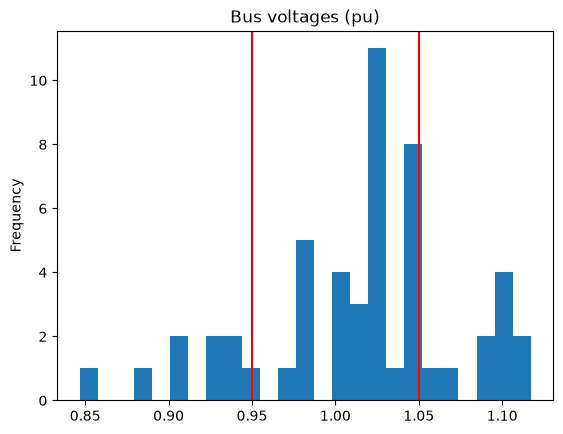

In [7]:
# Histogram of all bus voltage magnitudes; red lines mark the 0.95-1.05 pu band.
ax = net.res_bus.vm_pu.plot(kind="hist", bins=25, title="Bus voltages (pu)")
ax.axvline(0.95, color="r"); ax.axvline(1.05, color="r");

In [8]:
# One more pandas tool you will need today: filtering on TWO conditions.
# Each condition goes in its own parentheses; & means AND, | means OR.
mid = net.res_line[(net.res_line.loading_percent > 50)
                   & (net.res_line.loading_percent < 90)].copy()
# .copy() because we build a new table from the selection (and then add a column).
mid["line"] = net.line.loc[mid.index, "name"]
print(len(mid), "lines sit between 50% and 90% loading:")
mid[["line", "loading_percent"]].round(1)

12 lines sit between 50% and 90% loading:


,line,loading_percent
6,CL13,54.5
17,FL1,56.9
28,AL5,59.5
31,RL5,84.8
46,AL1,80.5
47,AL6,59.5
51,AL10,68.0
52,RL8,86.5
53,RL9,86.5
60,RL6,84.8


## 5. Three small tasks (10 minutes)

1. **Which lines are loaded above 90%?** How close is this system to its limits in the base case? (Keep this thought: this file is a *stressed planning snapshot* — in a few weeks you will find out exactly how much of this load the grid can carry securely.)
2. **Which buses are outside the 0.95–1.05 pu band?** Use `net.res_bus` together with `net.bus` to name them — combine two conditions the way the 50–90% cell above does. Expect a longish list (around twenty): the snapshot is deliberately stressed, so many buses out of band means you read it right, not that you built it wrong. Count strictly (`<` and `>`): a bus at exactly 1.050 pu is inside.
3. **Scale all loads up 5%** (`net.load.scaling = 1.05`), re-run the power flow, and compare the top loadings. What happened to line RL3?

In [9]:
# your work here


## Environment self-check

Run the cell below. If it prints `ALL OK`, your laptop is ready for the course. It checks your *environment*, not your task answers — and it resets Task 3's load scaling first, so it passes whether you did the tasks or not.

In [10]:
# Task 3 changed net.load.scaling — put the base case back and re-solve,
# so this check gives the same verdict no matter what you ran before it.
net.load.scaling = 1.0
pp.runpp(net, numba=False)

# Each assert checks one fact; a clean run prints the last line.
assert net.converged, "power flow did not converge"
# Svedala really does have 52 buses and 52 lines - the equal counts are a coincidence.
assert len(net.bus) == 52 and len(net.line) == 52, "unexpected network size"
assert abs(net.res_load.p_mw.sum() - 10981) < 10, "unexpected total load"
print("ALL OK — see you in Lab 1.")

ALL OK — see you in Lab 1.
